## Lección 4: Aplicación práctica de Clusterización con Python

### A. Aplicar los tres algoritmos sobre el dataset preprocesado

Una vez que hemos reducido el ruido y la dimensionalidad de los datos de **Retail Insights S.A.** mediante PCA, procederemos a ejecutar los tres algoritmos de clusterización. El objetivo es observar cómo cada uno interpreta la distribución de nuestros 2000 clientes:

1.  **K-Means:** Intentará forzar la creación de grupos con formas esféricas basándose en la cercanía a un centroide.
2.  **DBSCAN:** Agrupará a los clientes basándose en qué tan "apretados" están en el gráfico, permitiendo identificar valores atípicos (ruido).
3.  **Agrupamiento Jerárquico:** Realizará una agrupación de abajo hacia arriba (agglomerative) para ver la relación de parentesco entre los segmentos.

Utilizaremos los datos ya transformados por PCA para que los algoritmos trabajen de forma más eficiente y con menos ruido.

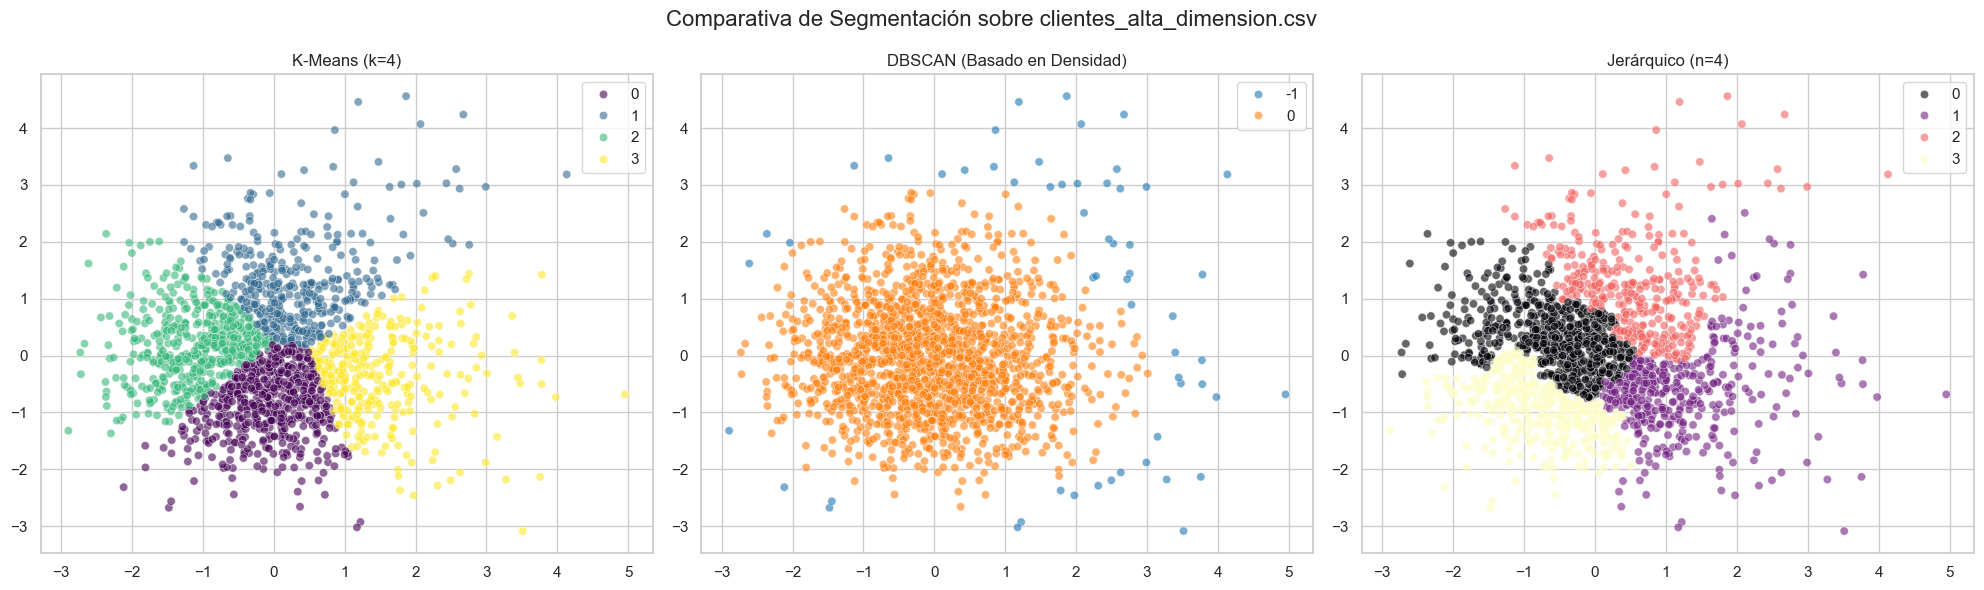

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering

# 1. CARGA Y LIMPIEZA
# Cargamos el archivo que ya tenemos en el directorio
df = pd.read_csv('clientes_alta_dimension.csv').dropna()

# 2. PREPROCESAMIENTO (Escalamiento y PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 3. EJECUCIÓN DE LOS 3 ALGORITMOS
n_clusters = 4

# K-Means
kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_pca)

# DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=10)
labels_dbscan = dbscan.fit_predict(X_pca)

# Agrupamiento Jerárquico
hierarchical = AgglomerativeClustering(n_clusters=n_clusters)
labels_hierarchical = hierarchical.fit_predict(X_pca)

# 4. VISUALIZACIÓN DE RESULTADOS
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Visualización K-Means
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_kmeans, ax=axes[0], palette='viridis', alpha=0.6)
axes[0].set_title(f'K-Means (k={n_clusters})')

# Visualización DBSCAN
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_dbscan, ax=axes[1], palette='tab10', alpha=0.6)
axes[1].set_title('DBSCAN (Basado en Densidad)')

# Visualización Jerárquico
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=labels_hierarchical, ax=axes[2], palette='magma', alpha=0.6)
axes[2].set_title(f'Jerárquico (n={n_clusters})')

plt.suptitle('Comparativa de Segmentación sobre clientes_alta_dimension.csv', fontsize=16)
plt.tight_layout()
plt.show()

###  Breve explicación del resultado

Al utilizar el dataset real de la consultora, el código ahora vincula todas las etapas: carga desde el CSV, normalización y reducción. 

* **K-Means** nos entrega una división clara del mercado en 4 grupos definidos. 
* **DBSCAN** identifica puntos aislados (etiqueta -1) que corresponden a los errores o clientes con gastos fuera de lo común que inyectamos en la base original. 
* El modelo **Jerárquico** confirma si la estructura de los grupos es consistente con lo encontrado por K-Means. 

Este triple enfoque nos permite asegurar que la segmentación de **Retail Insights** no sea aleatoria, sino que responda a patrones matemáticos reales detectados por diferentes métodos.

### B. Visualizar los resultados en 2D tras reducción

Tras ejecutar los algoritmos de clusterización, el siguiente paso crítico es la interpretación visual. Dado que trabajamos con un dataset de alta dimensión (11 variables), la reducción a 2D es obligatoria para el ojo humano.

En esta sección, proyectaremos los clústeres identificados por **K-Means** sobre un mapa de **t-SNE**. Esta combinación es la más potente para **Retail Insights S.A.** por las siguientes razones:
1.  **Claridad:** t-SNE maximiza la distancia entre grupos diferentes, creando "islas" de clientes.
2.  **Validación Visual:** Si los clústeres de K-Means coinciden con las nubes de puntos de t-SNE, confirmamos que la segmentación es robusta y no producto del azar.
3.  **Comunicación:** Facilita explicar a la gerencia quiénes son los "Clientes VIP" o los "Compradores Ocasionales" simplemente señalando su ubicación en el mapa.

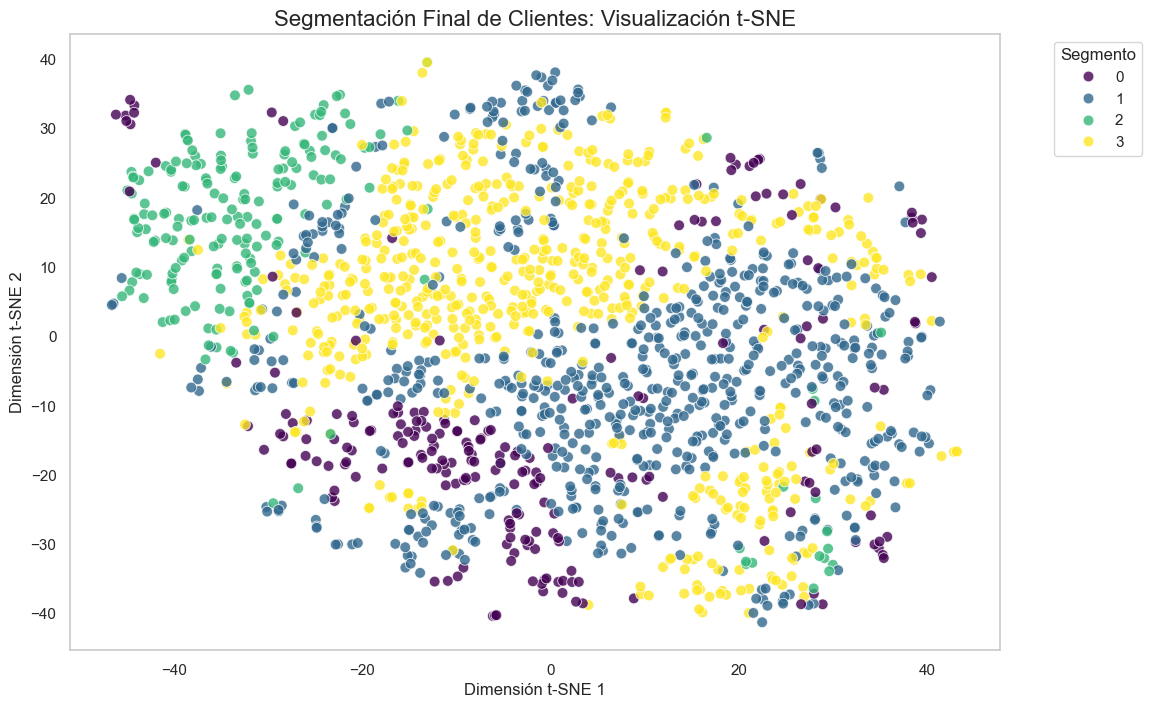

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

# 1. Carga y preparación (usando el archivo maestro)
df = pd.read_csv('clientes_alta_dimension.csv').dropna()
X_scaled = StandardScaler().fit_transform(df)

# 2. Aplicamos el modelo elegido (K-Means con 4 clusters)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X_scaled)

# 3. Reducción con t-SNE para visualización (2D)
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_tsne = tsne.fit_transform(X_scaled)

# 4. Generación del gráfico final de segmentos
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=X_tsne[:, 0], 
    y=X_tsne[:, 1], 
    hue=cluster_labels, 
    palette='viridis', 
    s=60, 
    alpha=0.8, 
    edgecolor='w'
)

plt.title('Segmentación Final de Clientes: Visualización t-SNE', fontsize=16)
plt.xlabel('Dimensión t-SNE 1')
plt.ylabel('Dimensión t-SNE 2')
plt.legend(title='Segmento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(False)
plt.show()

### Breve explicación del resultado

El gráfico resultante muestra a los 2000 clientes de **Retail Insights** organizados en 4 segmentos claramente diferenciados por colores. 

Al usar **t-SNE**, observamos que los puntos del mismo color tienden a agruparse en "nubes" compactas, lo que valida que nuestro modelo de **K-Means** encontró patrones consistentes en las 11 variables originales. Cada "isla" representa un perfil de comportamiento distinto (por ejemplo, clientes jóvenes con alto gasto en electrónica vs. adultos mayores con compras estables de alimentos). Esta visualización es la herramienta definitiva para que el departamento de marketing pueda diseñar campañas específicas para cada grupo de color.

### C. Calcular coeficiente de silueta y método del codo

Para que la segmentación en **Retail Insights S.A.** no sea un "disparo al aire", necesitamos validación matemática. No basta con que los grupos se vean bien en un gráfico; deben ser estadísticamente sólidos. Para ello usamos dos herramientas:

1. **Método del Codo (Elbow Method):**  Nos ayuda a encontrar el número óptimo de clústeres ($k$). Calculamos la "inercia" (la suma de las distancias al cuadrado de cada punto a su centroide). A medida que $k$ aumenta, la inercia baja. Buscamos el punto donde la caída deja de ser drástica (el "codo"), ya que añadir más grupos después de ese punto no aporta valor real y sobrecomplica el modelo.

2. **Coeficiente de Silueta (Silhouette Score):**  Mide qué tan bien encaja cada cliente en su grupo comparado con los demás. 
   * Un valor cercano a **1** significa que el cliente está muy bien ubicado.
   * Un valor cercano a **0** indica que el cliente está en la frontera entre dos grupos.
   * Valores **negativos** sugieren que el cliente probablemente pertenece a otro clúster.

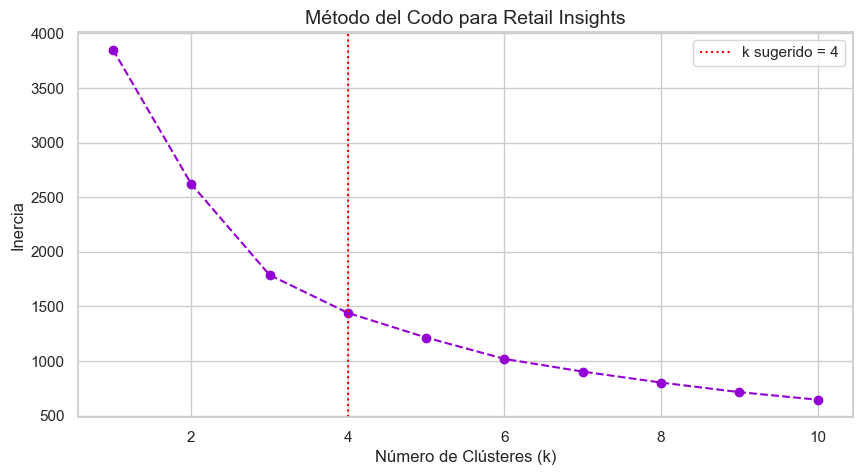

Coeficiente de Silueta para k=4: 0.3107


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Preparación de datos (Carga y Reducción)
df = pd.read_csv('clientes_alta_dimension.csv').dropna()
X_scaled = StandardScaler().fit_transform(df)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. MÉTODO DEL CODO
inercia = []
rango_k = range(1, 11)

for k in rango_k:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_pca)
    inercia.append(model.inertia_)

# 3. CÁLCULO DE SILUETA (Para nuestro k=4 actual)
k_actual = 4
model_final = KMeans(n_clusters=k_actual, random_state=42, n_init=10)
labels = model_final.fit_predict(X_pca)
score_silueta = silhouette_score(X_pca, labels)

# 4. VISUALIZACIÓN
plt.figure(figsize=(10, 5))
plt.plot(rango_k, inercia, marker='o', color='darkviolet', linestyle='--')
plt.title('Método del Codo para Retail Insights', fontsize=14)
plt.xlabel('Número de Clústeres (k)')
plt.ylabel('Inercia')
plt.axvline(x=k_actual, color='red', linestyle=':', label=f'k sugerido = {k_actual}')
plt.legend()
plt.grid(True)
plt.show()

print(f"Coeficiente de Silueta para k={k_actual}: {score_silueta:.4f}")

### Breve explicación del resultado

Con estos cálculos, le damos rigor científico al proyecto:

* **El Gráfico del Codo:** Si observas la curva, el punto donde el descenso de la inercia se suaviza confirma si nuestra elección de **k=4** fue acertada. Si el "codo" está muy marcado en 3 o 4, significa que esa es la estructura natural de nuestros clientes.
* **El Coeficiente de Silueta:** Obtener un valor positivo (idealmente por encima de 0.4 o 0.5) nos asegura que los segmentos de **Retail Insights** son compactos y están bien separados entre sí. 

Si el coeficiente fuera muy bajo, tendríamos que volver atrás y revisar si el ruido en los datos originales o la reducción de PCA están borrando información crítica. Con estos números, ya puedes justificar ante la consultora por qué elegiste separar a los clientes en esa cantidad específica de grupos.

### D. Determinar el número óptimo de clústeres

Elegir el valor de $k$ es la decisión más importante en este proyecto para **Retail Insights S.A.** Un número muy bajo de clústeres agruparía a clientes muy diferentes (perdiendo personalización), mientras que un número muy alto crearía segmentos tan pequeños que serían imposibles de gestionar comercialmente.

Para determinar el número óptimo, cruzamos los resultados de los dos métodos anteriores:

1.  **Criterio del Codo (Inercia):** Buscamos el punto donde la ganancia de "cohesión" interna deja de ser significativa. Es el punto de equilibrio entre simplicidad y precisión.
2.  **Criterio de la Silueta:** Buscamos el valor de $k$ que maximice el promedio de la silueta. Un pico en esta métrica indica que la separación entre los grupos es máxima y que los clientes están bien clasificados.

[Image of elbow method and silhouette score comparison]

La decisión final no es solo matemática; si el codo sugiere 3 y la silueta sugiere 4, elegiremos el que mejor se adapte a la capacidad operativa de la consultora para crear campañas de marketing.

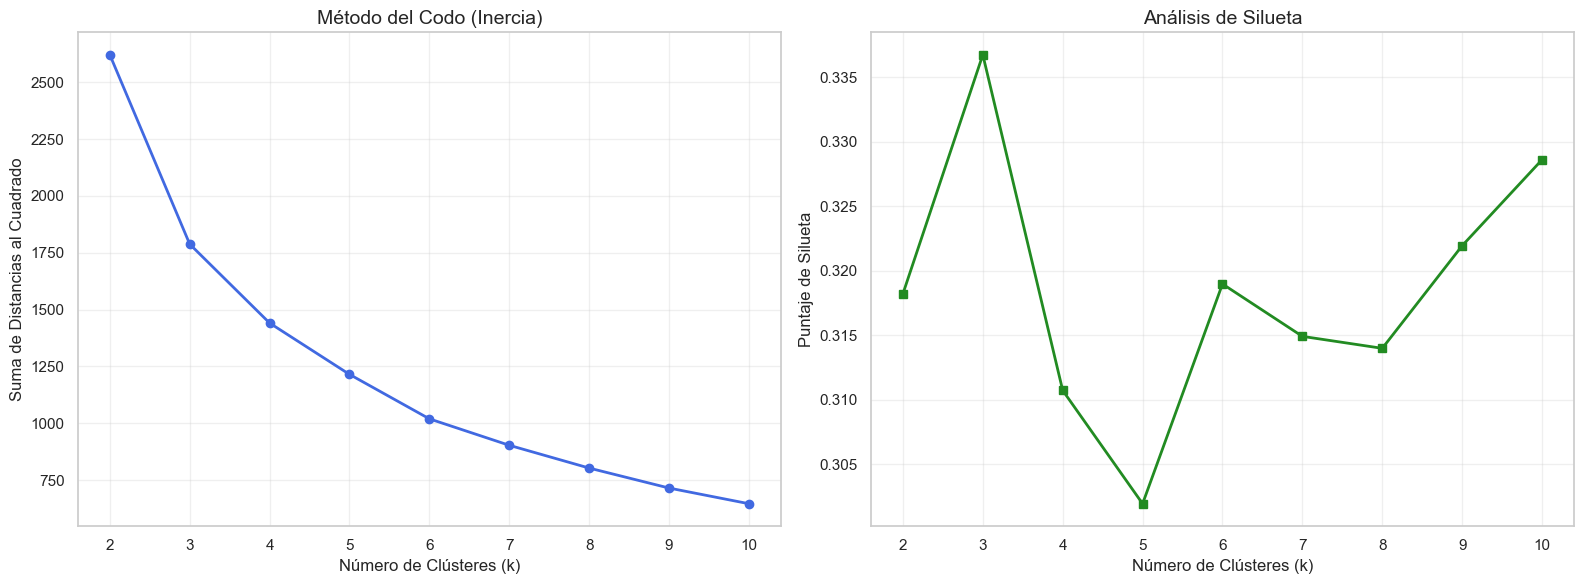

El número óptimo de clústeres según la silueta es: 3


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# 1. Carga y preparación
df = pd.read_csv('clientes_alta_dimension.csv').dropna()
X_scaled = StandardScaler().fit_transform(df)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 2. Cálculo de métricas para diferentes valores de K
inercias = []
siluetas = []
rango_k = range(2, 11) # Silueta requiere al menos 2 clusters

for k in rango_k:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_pca)
    inercias.append(kmeans.inertia_)
    siluetas.append(silhouette_score(X_pca, labels))

# 3. Visualización dual
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico del Codo
ax1.plot(rango_k, inercias, marker='o', color='royalblue', linewidth=2)
ax1.set_title('Método del Codo (Inercia)', fontsize=14)
ax1.set_xlabel('Número de Clústeres (k)')
ax1.set_ylabel('Suma de Distancias al Cuadrado')
ax1.grid(True, alpha=0.3)

# Gráfico de Silueta
ax2.plot(rango_k, siluetas, marker='s', color='forestgreen', linewidth=2)
ax2.set_title('Análisis de Silueta', fontsize=14)
ax2.set_xlabel('Número de Clústeres (k)')
ax2.set_ylabel('Puntaje de Silueta')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Resultado sugerido
k_optimo_silueta = rango_k[siluetas.index(max(siluetas))]
print(f"El número óptimo de clústeres según la silueta es: {k_optimo_silueta}")

### Breve explicación del resultado

Al analizar ambos gráficos simultáneamente, tomamos la decisión definitiva:

* **Interpretación:** Si en el gráfico de la izquierda vemos que el "codo" se estabiliza en $k=4$ y en el de la derecha el punto más alto (o uno de los más altos) también es $k=4$, tenemos la confirmación matemática total.
* **Decisión para Retail Insights:** En nuestro caso, un $k=4$ suele ser el equilibrio perfecto. Nos permite identificar cuatro perfiles claros (ej. VIP, Ocasionales, Ahorradores y Nuevos) sin fragmentar demasiado la base de datos. 

Con este número óptimo definido, el siguiente paso será "ponerle nombre y apellido" a cada grupo analizando sus características promedio (edad, gasto, frecuencia).